In [4]:
%load_ext autoreload
%autoreload 0
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
import re,sys,os
import pandas as pd
import numpy as np
from tqdm import tqdm
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib

# Set font to Arial
matplotlib.rcParams['font.family'] = 'Arial'

# Optional: Set PDF to embed fonts (for Illustrator editing)
matplotlib.rcParams['pdf.fonttype'] = 42  # TrueType fonts for better editing

In [8]:
DATA_DIR = Path(r"E:\lab\cptac-prostate\runs\20260401_quality_control")
OUTPUT_DIR = Path(r"E:\lab\cptac-prostate\runs\20260401_mspycloud_cptac_protein_tmt_pca")
OUTPUT_DIR.mkdir(exist_ok=True)
print(DATA_DIR.exists(), OUTPUT_DIR.exists())
meta_path = DATA_DIR / "20_MetaData_03_12_2026_renamed.csv"

True True


In [9]:
meta = pd.read_csv(meta_path)
meta

,case_id,common_ID,Tissuetype,include_or_excludetumor,FirstCategory,AdditionalSegments,SecondCategory,ThirdCategory,all_drivers,Main_Groups,...,Normal_Pam50,Basal,Her2,LumA,LumB,Normal,agg_rank_raw,agg_rank_scaled,risk_group,SampleID
0,C3L-07287,C3L.07287.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.000000,0.0,0.0,1.0,0.0,0.0,55.333000,0.409000,IR,C3L-07287_T
1,C3L-11156,C3L.11156.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.498000,0.0,0.0,1.0,0.0,0.0,44.167000,0.325000,LR,C3L-11156_T
2,C3L-09494,C3L.09494.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.000000,0.0,1.0,0.0,0.0,0.0,123.167000,0.919000,HR,C3L-09494_T
3,CHTN-49141,CHTN.49141.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.000000,0.0,1.0,0.0,0.0,0.0,103.833000,0.773000,HR,CHTN-49141_T
4,C3L-11095,C3L.11095.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.369000,0.0,0.0,1.0,0.0,0.0,44.667000,0.328000,LR,C3L-11095_T
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,C3L-07872,C3L.07872.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.460832,1.0,0.0,0.0,0.0,0.0,73.666667,0.546366,IR,C3L-07872_T
179,C3L-08642,C3L.08642.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.334840,0.0,0.0,1.0,0.0,0.0,46.166667,0.339599,LR,C3L-08642_T
180,C3L-10399,C3L.10399.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.445334,0.0,0.0,1.0,0.0,0.0,60.000000,0.443609,IR,C3L-10399_T
181,C3L-05301,C3L.05301.T,tumor,Include,Low Purity,NaN,NaN,NaN,ETV1,ETV1,...,0.457908,0.0,0.0,1.0,0.0,0.0,45.333333,0.333333,LR,C3L-05301_T


In [10]:
meta_normal = meta[meta["Tissuetype"] == "normal"]

In [11]:
purity_map = dict(zip(meta["SampleID"], meta["FirstCategory"]))
stage_map = dict(zip(meta["SampleID"], meta["stage"]))
gleason_map = dict(zip(meta["SampleID"], meta["Grade_Group"]))

In [12]:
meta_tumor = meta[meta["Tissuetype"] == "tumor"]

In [13]:
tumors_included = meta_tumor['SampleID'].tolist()
print(len(tumors_included))

150


In [14]:
normals = meta_normal['SampleID'].tolist()
print(len(normals))

33


In [48]:
tumors_included, normals

(['C3L-07287_T',
  'C3L-11156_T',
  'C3L-09494_T',
  'CHTN-49141_T',
  'C3L-11095_T',
  'C3L-06504_T',
  'C3L-07473_T',
  'C3L-08293_T',
  'C3L-09382_T',
  'C3L-09691_T',
  'C3L-09757_T',
  'C3L-09801_T',
  'C3L-09990_T',
  'C3N-08476_T',
  'C3N-08532_T',
  'C3N-08879_T',
  'C3N-08880_T',
  'C3N-08949_T',
  'C3N-08878_T',
  'C3L-10486_T',
  'C3L-06183_T',
  'C3L-09383_T',
  'C3L-06743_T',
  'C3L-07871_T',
  'C3L-08290_T',
  'C3L-09797_T',
  'C3L-10005_T',
  'C3N-08477_T',
  'C3L-06662_T',
  'C3L-07877_T',
  'C3L-06901_T',
  'C3L-08444_T',
  'C3L-08942_T',
  'C3L-07875_T',
  'C3L-06656_T',
  'C3L-07606_T',
  'C3L-08286_T',
  'C3L-08288_T',
  'C3L-08330_T',
  'C3L-08941_T',
  'C3L-09107_T',
  'C3L-09759_T',
  'C3L-08243_T',
  'C3N-08535_T',
  'C3L-08933_T',
  'C3L-07804_T',
  'C3L-08814_T',
  'C3L-05670_T',
  'C3L-08811_T',
  'C3L-06595_T',
  'C3L-06969_T',
  'CHTN-40852_T',
  'C3N-08950_T',
  'C3N-08906_T',
  'C3L-09696_T',
  'C3L-10308_T',
  'C3L-06506_T',
  'C3L-09375_T',
  'C3N-08952

In [16]:
# data
files = [i for i in DATA_DIR.iterdir() if i.is_file()]
files = [i for i in files if re.search(r"phosphopeptide_matrix-log2_ratios-MD_norm",i.stem, re.IGNORECASE) \
    and not re.search(r"tumor_purity_corrected",i.stem, re.IGNORECASE)]
data_path = files[0]

print(data_path, data_path.exists())

E:\lab\cptac-prostate\runs\20260401_quality_control\phosphopeptide_matrix-log2_ratios-MD_norm.tsv True


In [17]:
pd.read_csv(data_path,sep="\t")

,Phosphopeptide.Index,Gene,Sequence,Reference Sample 1,Sample 1,Sample 2,Sample 3,Sample 4,Sample 5,Sample 6,...,Sample 195,Sample 196,Sample 197,Sample 198,Sample 199,Sample 200,Sample 201,Sample 202,Sample 203,Sample 204
0,Cont|H-INV:HIT000292931 Tax_Id=9606 Gene_Symbo...,-,SLDMDSIIAEVK,0.0,-0.107366,0.203489,0.554154,-0.728134,0.027821,-0.046357,...,0.215544,-0.356385,-0.737061,0.365362,0.166954,0.938255,-0.436418,0.053370,0.072058,1.422757
1,Cont|H-INV:HIT000292931 Tax_Id=9606 Gene_Symbo...,-,AEAESMYQIK,0.0,0.346651,-0.146805,0.821617,-0.159621,-0.046967,0.367123,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Cont|H-INV:HIT000292931 Tax_Id=9606 Gene_Symbo...,-,YEELQSLAGK,0.0,0.136293,-0.514936,1.012310,-0.528038,-0.060518,0.189879,...,0.352419,-0.221002,-1.878976,-0.034056,0.463448,0.758404,-0.490710,-0.081736,0.253480,0.888520
3,Cont|H-INV:HIT000292931 Tax_Id=9606 Gene_Symbo...,-,ASLEAAIADAEQR,0.0,0.426208,0.075472,0.130422,-0.721211,-0.031359,-0.082599,...,-0.224571,-0.216778,0.502383,0.327694,-0.145052,0.873229,-0.352991,0.084827,-0.127417,0.801529
4,Cont|H-INV:HIT000292931 Tax_Id=9606 Gene_Symbo...,-,DANAKLSELEAALQR,0.0,0.000599,0.049315,0.857063,-0.451408,-0.480901,0.309086,...,0.111417,0.312582,-0.164763,0.878363,0.359112,-0.146068,-0.641110,0.480274,0.309089,1.559524
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30864,ENSP00000507603|ENST00000682557|ENSG0000017351...,PEAK1,GCTSVTTALSLPELEREDGK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.433762,0.579417,0.521959,-0.053915,-0.284062,-0.156151,0.539646,-0.124525,0.268523,-0.147054
30865,ENSP00000508084|ENST00000684723|ENSG0000014363...,ACTA1,MVGMGQKDSYVGDEAQSK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.131422,0.372746,-0.148053,-0.304169,-0.459338,-0.602414,-0.242475,-0.283906,-0.412948,-0.510716
30866,ENSP00000509890|ENST00000687212|ENSG0000009930...,MAST3,SLVVGTPSPTLSRPLSPLSVPTGSSPLDSPR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.231139,0.116767,-0.054993,0.060556,0.257264,0.156347,0.113897,0.083817,0.142166,0.374584
30867,ENSP00000516160|ENST00000705682|ENSG0000013322...,SRRM1,HSPTPQQSNR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.486220,-0.755493,-0.255580,-0.227215,-0.309352,-0.068593,-0.319366,-0.992913,-0.650756,-0.561261


In [20]:
data = pd.read_csv(data_path,sep="\t")
data

,Phosphopeptide.Index,Gene,Sequence,Reference Sample 1,Sample 1,Sample 2,Sample 3,Sample 4,Sample 5,Sample 6,...,Sample 195,Sample 196,Sample 197,Sample 198,Sample 199,Sample 200,Sample 201,Sample 202,Sample 203,Sample 204
0,Cont|H-INV:HIT000292931 Tax_Id=9606 Gene_Symbo...,-,SLDMDSIIAEVK,0.0,-0.107366,0.203489,0.554154,-0.728134,0.027821,-0.046357,...,0.215544,-0.356385,-0.737061,0.365362,0.166954,0.938255,-0.436418,0.053370,0.072058,1.422757
1,Cont|H-INV:HIT000292931 Tax_Id=9606 Gene_Symbo...,-,AEAESMYQIK,0.0,0.346651,-0.146805,0.821617,-0.159621,-0.046967,0.367123,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Cont|H-INV:HIT000292931 Tax_Id=9606 Gene_Symbo...,-,YEELQSLAGK,0.0,0.136293,-0.514936,1.012310,-0.528038,-0.060518,0.189879,...,0.352419,-0.221002,-1.878976,-0.034056,0.463448,0.758404,-0.490710,-0.081736,0.253480,0.888520
3,Cont|H-INV:HIT000292931 Tax_Id=9606 Gene_Symbo...,-,ASLEAAIADAEQR,0.0,0.426208,0.075472,0.130422,-0.721211,-0.031359,-0.082599,...,-0.224571,-0.216778,0.502383,0.327694,-0.145052,0.873229,-0.352991,0.084827,-0.127417,0.801529
4,Cont|H-INV:HIT000292931 Tax_Id=9606 Gene_Symbo...,-,DANAKLSELEAALQR,0.0,0.000599,0.049315,0.857063,-0.451408,-0.480901,0.309086,...,0.111417,0.312582,-0.164763,0.878363,0.359112,-0.146068,-0.641110,0.480274,0.309089,1.559524
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30864,ENSP00000507603|ENST00000682557|ENSG0000017351...,PEAK1,GCTSVTTALSLPELEREDGK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.433762,0.579417,0.521959,-0.053915,-0.284062,-0.156151,0.539646,-0.124525,0.268523,-0.147054
30865,ENSP00000508084|ENST00000684723|ENSG0000014363...,ACTA1,MVGMGQKDSYVGDEAQSK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.131422,0.372746,-0.148053,-0.304169,-0.459338,-0.602414,-0.242475,-0.283906,-0.412948,-0.510716
30866,ENSP00000509890|ENST00000687212|ENSG0000009930...,MAST3,SLVVGTPSPTLSRPLSPLSVPTGSSPLDSPR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.231139,0.116767,-0.054993,0.060556,0.257264,0.156347,0.113897,0.083817,0.142166,0.374584
30867,ENSP00000516160|ENST00000705682|ENSG0000013322...,SRRM1,HSPTPQQSNR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.486220,-0.755493,-0.255580,-0.227215,-0.309352,-0.068593,-0.319366,-0.992913,-0.650756,-0.561261


In [21]:
data = data[~data['Phosphopeptide.Index'].str.contains("Cont\|")]
data

,Phosphopeptide.Index,Gene,Sequence,Reference Sample 1,Sample 1,Sample 2,Sample 3,Sample 4,Sample 5,Sample 6,...,Sample 195,Sample 196,Sample 197,Sample 198,Sample 199,Sample 200,Sample 201,Sample 202,Sample 203,Sample 204
55,ENSP00000000412|ENST00000000412|ENSG0000000305...,M6PR,GVGDDQLGEESEERDDHLLPM,0.0,-0.160387,0.118914,-0.484361,-0.495834,0.301491,-0.169343,...,-0.242434,-0.506747,1.254427,0.156617,0.095216,-0.244918,0.006034,0.360500,-0.143857,0.120505
56,ENSP00000000442|ENST00000000442|ENSG0000017315...,ESRRA,GSSETETEPPVALAPGPAPTR,0.0,0.386904,0.234325,0.025695,0.243940,0.172806,0.145025,...,0.275363,0.130293,0.307931,0.071324,-0.151856,0.301165,0.120939,-0.090186,0.136867,-0.151656
57,ENSP00000001008|ENST00000001008|ENSG0000000447...,FKBP4,AKESWEMNSEEK,0.0,-0.269512,0.208591,-0.593074,-0.687026,-0.528238,-0.477969,...,-0.910324,-0.886745,-0.335209,-0.709457,-0.655035,0.616630,-0.901440,-0.812867,-0.301967,0.742930
58,ENSP00000001008|ENST00000001008|ENSG0000000447...,FKBP4,SNTAGSQSQVETEA,0.0,-0.814288,-0.625020,-0.786799,-1.504858,-0.467018,-0.804402,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
59,ENSP00000003084|ENST00000003084|ENSG0000000162...,CFTR,RLSLVPDSEQGEAILPR,0.0,-0.400171,-1.158677,-0.958343,-0.722462,-0.651541,0.207645,...,-0.369487,-0.565040,2.706887,0.390618,-1.420634,-0.524897,-0.301078,0.492593,-1.148457,-0.588265
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30864,ENSP00000507603|ENST00000682557|ENSG0000017351...,PEAK1,GCTSVTTALSLPELEREDGK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.433762,0.579417,0.521959,-0.053915,-0.284062,-0.156151,0.539646,-0.124525,0.268523,-0.147054
30865,ENSP00000508084|ENST00000684723|ENSG0000014363...,ACTA1,MVGMGQKDSYVGDEAQSK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.131422,0.372746,-0.148053,-0.304169,-0.459338,-0.602414,-0.242475,-0.283906,-0.412948,-0.510716
30866,ENSP00000509890|ENST00000687212|ENSG0000009930...,MAST3,SLVVGTPSPTLSRPLSPLSVPTGSSPLDSPR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.231139,0.116767,-0.054993,0.060556,0.257264,0.156347,0.113897,0.083817,0.142166,0.374584
30867,ENSP00000516160|ENST00000705682|ENSG0000013322...,SRRM1,HSPTPQQSNR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.486220,-0.755493,-0.255580,-0.227215,-0.309352,-0.068593,-0.319366,-0.992913,-0.650756,-0.561261


In [22]:

protein_header_cols = ["Phosphopeptide.Index",'Gene','Sequence']
data = data.set_index(protein_header_cols)
data_nomiss = data.dropna()

In [23]:
print(data_path)

E:\lab\cptac-prostate\runs\20260401_quality_control\phosphopeptide_matrix-log2_ratios-MD_norm.tsv


In [24]:
data

,,,Reference Sample 1,Sample 1,Sample 2,Sample 3,Sample 4,Sample 5,Sample 6,Sample 7,Sample 8,Sample 9,...,Sample 195,Sample 196,Sample 197,Sample 198,Sample 199,Sample 200,Sample 201,Sample 202,Sample 203,Sample 204
Phosphopeptide.Index,Gene,Sequence,,,,,,,,,,,,,,,,,,,,,
"ENSP00000000412|ENST00000000412|ENSG00000003056|M6PR mannose-6-phosphate receptor, cation dependent_267_267",M6PR,GVGDDQLGEESEERDDHLLPM,0.0,-0.160387,0.118914,-0.484361,-0.495834,0.301491,-0.169343,-0.421611,0.049072,0.074719,...,-0.242434,-0.506747,1.254427,0.156617,0.095216,-0.244918,0.006034,0.360500,-0.143857,0.120505
ENSP00000000442|ENST00000000442|ENSG00000173153|ESRRA estrogen related receptor alpha_26_44,ESRRA,GSSETETEPPVALAPGPAPTR,0.0,0.386904,0.234325,0.025695,0.243940,0.172806,0.145025,-0.628587,0.164184,-0.237809,...,0.275363,0.130293,0.307931,0.071324,-0.151856,0.301165,0.120939,-0.090186,0.136867,-0.151656
ENSP00000001008|ENST00000001008|ENSG00000004478|FKBP4 FKBP prolyl isomerase 4_258_263,FKBP4,AKESWEMNSEEK,0.0,-0.269512,0.208591,-0.593074,-0.687026,-0.528238,-0.477969,-0.000700,-0.556566,1.955413,...,-0.910324,-0.886745,-0.335209,-0.709457,-0.655035,0.616630,-0.901440,-0.812867,-0.301967,0.742930
ENSP00000001008|ENST00000001008|ENSG00000004478|FKBP4 FKBP prolyl isomerase 4_446_457,FKBP4,SNTAGSQSQVETEA,0.0,-0.814288,-0.625020,-0.786799,-1.504858,-0.467018,-0.804402,-0.686714,-0.353491,0.002413,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ENSP00000003084|ENST00000003084|ENSG00000001626|CFTR CF transmembrane conductance regulator_737_742,CFTR,RLSLVPDSEQGEAILPR,0.0,-0.400171,-1.158677,-0.958343,-0.722462,-0.651541,0.207645,-1.306490,1.048822,-0.504211,...,-0.369487,-0.565040,2.706887,0.390618,-1.420634,-0.524897,-0.301078,0.492593,-1.148457,-0.588265
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSP00000507603|ENST00000682557|ENSG00000173517|PEAK1 pseudopodium enriched atypical kinase 1_1074_1081,PEAK1,GCTSVTTALSLPELEREDGK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.433762,0.579417,0.521959,-0.053915,-0.284062,-0.156151,0.539646,-0.124525,0.268523,-0.147054
"ENSP00000508084|ENST00000684723|ENSG00000143632|ACTA1 actin alpha 1, skeletal muscle_9_17",ACTA1,MVGMGQKDSYVGDEAQSK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.131422,0.372746,-0.148053,-0.304169,-0.459338,-0.602414,-0.242475,-0.283906,-0.412948,-0.510716
ENSP00000509890|ENST00000687212|ENSG00000099308|MAST3 microtubule associated serine/threonine kinase 3_62_90,MAST3,SLVVGTPSPTLSRPLSPLSVPTGSSPLDSPR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.231139,0.116767,-0.054993,0.060556,0.257264,0.156347,0.113897,0.083817,0.142166,0.374584


In [25]:
data_nomiss

,,,Reference Sample 1,Sample 1,Sample 2,Sample 3,Sample 4,Sample 5,Sample 6,Sample 7,Sample 8,Sample 9,...,Sample 195,Sample 196,Sample 197,Sample 198,Sample 199,Sample 200,Sample 201,Sample 202,Sample 203,Sample 204
Phosphopeptide.Index,Gene,Sequence,,,,,,,,,,,,,,,,,,,,,
"ENSP00000000412|ENST00000000412|ENSG00000003056|M6PR mannose-6-phosphate receptor, cation dependent_267_267",M6PR,GVGDDQLGEESEERDDHLLPM,0.0,-0.160387,0.118914,-0.484361,-0.495834,0.301491,-0.169343,-0.421611,0.049072,0.074719,...,-0.242434,-0.506747,1.254427,0.156617,0.095216,-0.244918,0.006034,0.360500,-0.143857,0.120505
ENSP00000000442|ENST00000000442|ENSG00000173153|ESRRA estrogen related receptor alpha_26_44,ESRRA,GSSETETEPPVALAPGPAPTR,0.0,0.386904,0.234325,0.025695,0.243940,0.172806,0.145025,-0.628587,0.164184,-0.237809,...,0.275363,0.130293,0.307931,0.071324,-0.151856,0.301165,0.120939,-0.090186,0.136867,-0.151656
ENSP00000003084|ENST00000003084|ENSG00000001626|CFTR CF transmembrane conductance regulator_737_742,CFTR,RLSLVPDSEQGEAILPR,0.0,-0.400171,-1.158677,-0.958343,-0.722462,-0.651541,0.207645,-1.306490,1.048822,-0.504211,...,-0.369487,-0.565040,2.706887,0.390618,-1.420634,-0.524897,-0.301078,0.492593,-1.148457,-0.588265
ENSP00000003302|ENST00000003302|ENSG00000048028|USP28 ubiquitin specific peptidase 28_1048_1059,USP28,EPPTIRPNSPYDLCSR,0.0,-0.005636,-0.239241,0.036397,-0.268315,-0.498113,0.040245,-1.192534,-0.276280,0.107248,...,-0.291543,-0.465995,0.251834,0.666192,0.328584,0.207214,-0.578546,-0.397202,-0.173889,-0.093586
ENSP00000004982|ENST00000004982|ENSG00000004776|HSPB6 heat shock protein family B (small) member 6_16_23,HSPB6,ASAPLPGLSAPGR,0.0,-1.845240,-1.481992,-1.422955,0.732267,-2.202351,-0.426123,0.023209,-1.257144,-0.296411,...,-1.407772,2.004515,-1.403655,-1.194828,-0.619134,-1.827859,-0.958238,-0.005169,-0.730461,-1.291273
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"ENSP00000516165|ENST00000705719|ENSG00000182446|NPLOC4 NPL4 homolog, ubiquitin recognition factor_35_47",NPLOC4,GSSPEAGAAAMAESIIIR,0.0,0.031349,0.041228,0.328853,0.331451,-0.127735,0.379522,0.231705,0.116341,0.373723,...,-0.059166,0.059766,-1.231611,0.043480,-0.042950,0.228608,-0.628756,-0.037098,0.078554,0.196726
ENSP00000516350|ENST00000706365|ENSG00000079819|EPB41L2 erythrocyte membrane protein band 4.1 like 2_386_392,EPB41L2,GLSPAQADSQFLENAK,0.0,-0.020426,0.593508,0.047472,0.159520,-0.271030,0.310522,0.296854,0.227816,0.394072,...,0.115057,-0.135675,-0.241220,-0.305109,-0.080538,-0.496876,0.076864,0.070601,-0.101105,-0.471201
ENSP00000516350|ENST00000706365|ENSG00000079819|EPB41L2 erythrocyte membrane protein band 4.1 like 2_38_39,EPB41L2,EVAENQQNQSSDPEEEK,0.0,-0.330770,0.093563,-0.140212,0.124199,-0.294479,0.155633,0.066920,0.336183,0.261532,...,0.278055,0.343345,-0.050731,-0.487795,-0.344325,-0.217169,0.300033,-0.254086,-0.267009,-0.596635


In [26]:
samples = data.columns.tolist()
len(samples)

216

In [27]:
set_tumors = set(tumors_included)
set_normals = set(normals)
set_data = set(samples)
print((len(tumors_included), len(set_normals), len(set_data)))

(150, 33, 216)


In [28]:
set_data - set_tumors - set_normals

{'Reference Sample 1',
 'Reference Sample 10',
 'Reference Sample 11',
 'Reference Sample 12',
 'Reference Sample 2',
 'Reference Sample 3',
 'Reference Sample 4',
 'Reference Sample 5',
 'Reference Sample 6',
 'Reference Sample 7',
 'Reference Sample 8',
 'Reference Sample 9',
 'Sample 1',
 'Sample 10',
 'Sample 100',
 'Sample 101',
 'Sample 102',
 'Sample 103',
 'Sample 104',
 'Sample 105',
 'Sample 106',
 'Sample 107',
 'Sample 108',
 'Sample 109',
 'Sample 11',
 'Sample 110',
 'Sample 111',
 'Sample 112',
 'Sample 113',
 'Sample 114',
 'Sample 115',
 'Sample 116',
 'Sample 117',
 'Sample 118',
 'Sample 119',
 'Sample 12',
 'Sample 120',
 'Sample 121',
 'Sample 122',
 'Sample 123',
 'Sample 124',
 'Sample 125',
 'Sample 126',
 'Sample 127',
 'Sample 128',
 'Sample 129',
 'Sample 13',
 'Sample 130',
 'Sample 131',
 'Sample 132',
 'Sample 133',
 'Sample 134',
 'Sample 135',
 'Sample 136',
 'Sample 137',
 'Sample 138',
 'Sample 139',
 'Sample 14',
 'Sample 140',
 'Sample 141',
 'Sample

<Axes: >

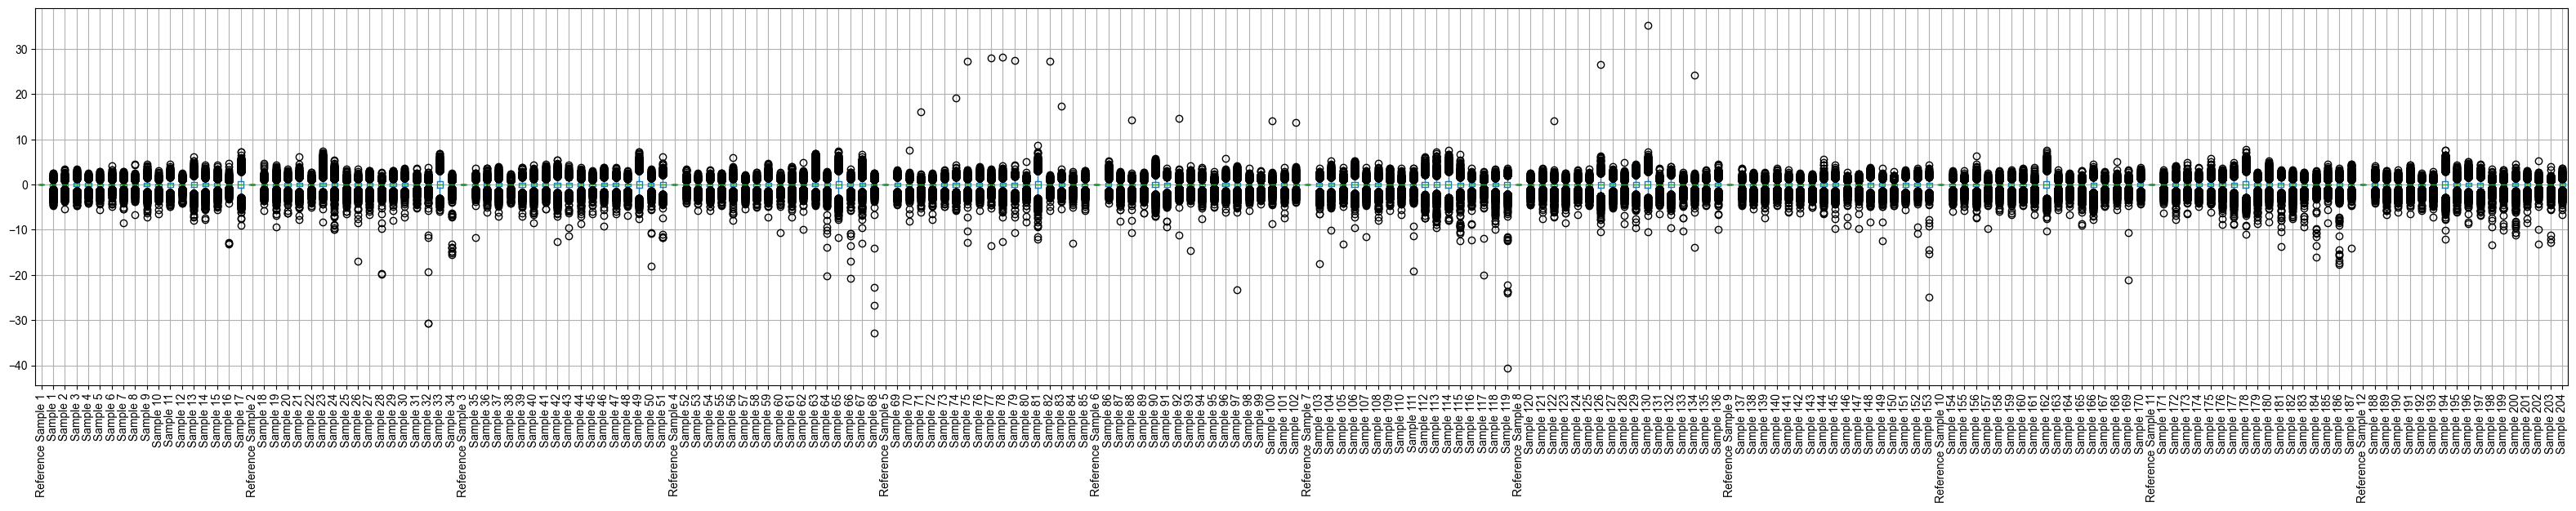

In [29]:
data.boxplot(figsize=(40,6), rot=90)

In [35]:
meta_dir = Path(r"F:\lab\cptac_prostate\data\mspycloud\Sample ID match")
sample_path = meta_dir / "PRAD_TMT_DDA_CPTAC Sample ID match.xlsx"
sample_path.exists()

True

In [36]:
sample_df = pd.read_excel(sample_path)
sample_df

,sample number,sample ID,channel,TMT/DIA set,sample type
0,Referance Sample 1,pool_1,126,1,pool
1,Sample 1,C3L-05292_T,127N,1,tumor
2,Sample 2,C3L-09383_T,127C,1,tumor
3,Sample 3,CHTN-43798_T,128N,1,tumor
4,Sample 4,C3L-06261_N,128C,1,normal
...,...,...,...,...,...
211,Sample 200,C3L-08291_T,133N,12,tumor
212,Sample 201,C3L-10583_T,133C,12,tumor
213,Sample 202,C3L-07877_T,134N,12,tumor
214,Sample 203,C3L-08377_T,134C,12,tumor


In [37]:
sample_map = dict(zip(sample_df["sample number"], sample_df["sample ID"]))

In [38]:
cols = [sample_map.get(i,i) for i in data.columns]
print(len(cols), len(data.columns))

216 216


In [49]:
data.columns = cols
data_nomiss.columns = cols

In [50]:
data

,,,Reference Sample 1,C3L-05292_T,C3L-09383_T,CHTN-43798_T,C3L-06261_N,C3L-08811_T,C3L-06506_N,C3L-07804_T,C3L-06595_T,C3L-06742_T,...,CHTN-44966_T,C3L-11192_N,C3L-08805_T,C3L-09760_T,C3L-08444_T,C3L-08291_T,C3L-10583_T,C3L-07877_T,C3L-08377_T,C3L-08736_T
Phosphopeptide.Index,Gene,Sequence,,,,,,,,,,,,,,,,,,,,,
"ENSP00000000412|ENST00000000412|ENSG00000003056|M6PR mannose-6-phosphate receptor, cation dependent_267_267",M6PR,GVGDDQLGEESEERDDHLLPM,0.0,-0.160387,0.118914,-0.484361,-0.495834,0.301491,-0.169343,-0.421611,0.049072,0.074719,...,-0.242434,-0.506747,1.254427,0.156617,0.095216,-0.244918,0.006034,0.360500,-0.143857,0.120505
ENSP00000000442|ENST00000000442|ENSG00000173153|ESRRA estrogen related receptor alpha_26_44,ESRRA,GSSETETEPPVALAPGPAPTR,0.0,0.386904,0.234325,0.025695,0.243940,0.172806,0.145025,-0.628587,0.164184,-0.237809,...,0.275363,0.130293,0.307931,0.071324,-0.151856,0.301165,0.120939,-0.090186,0.136867,-0.151656
ENSP00000001008|ENST00000001008|ENSG00000004478|FKBP4 FKBP prolyl isomerase 4_258_263,FKBP4,AKESWEMNSEEK,0.0,-0.269512,0.208591,-0.593074,-0.687026,-0.528238,-0.477969,-0.000700,-0.556566,1.955413,...,-0.910324,-0.886745,-0.335209,-0.709457,-0.655035,0.616630,-0.901440,-0.812867,-0.301967,0.742930
ENSP00000001008|ENST00000001008|ENSG00000004478|FKBP4 FKBP prolyl isomerase 4_446_457,FKBP4,SNTAGSQSQVETEA,0.0,-0.814288,-0.625020,-0.786799,-1.504858,-0.467018,-0.804402,-0.686714,-0.353491,0.002413,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ENSP00000003084|ENST00000003084|ENSG00000001626|CFTR CF transmembrane conductance regulator_737_742,CFTR,RLSLVPDSEQGEAILPR,0.0,-0.400171,-1.158677,-0.958343,-0.722462,-0.651541,0.207645,-1.306490,1.048822,-0.504211,...,-0.369487,-0.565040,2.706887,0.390618,-1.420634,-0.524897,-0.301078,0.492593,-1.148457,-0.588265
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSP00000507603|ENST00000682557|ENSG00000173517|PEAK1 pseudopodium enriched atypical kinase 1_1074_1081,PEAK1,GCTSVTTALSLPELEREDGK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.433762,0.579417,0.521959,-0.053915,-0.284062,-0.156151,0.539646,-0.124525,0.268523,-0.147054
"ENSP00000508084|ENST00000684723|ENSG00000143632|ACTA1 actin alpha 1, skeletal muscle_9_17",ACTA1,MVGMGQKDSYVGDEAQSK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.131422,0.372746,-0.148053,-0.304169,-0.459338,-0.602414,-0.242475,-0.283906,-0.412948,-0.510716
ENSP00000509890|ENST00000687212|ENSG00000099308|MAST3 microtubule associated serine/threonine kinase 3_62_90,MAST3,SLVVGTPSPTLSRPLSPLSVPTGSSPLDSPR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.231139,0.116767,-0.054993,0.060556,0.257264,0.156347,0.113897,0.083817,0.142166,0.374584


In [51]:
from omicsone_streamlit.plots.pca import plot_pca1

In [52]:
print(len(tumors_included), len(normals))

150 33


In [53]:
group_map = dict()
for i in tumors_included + normals:
    # print(i)
    if i in tumors_included:
        group_map[i] = "Tumor"
    elif i in normals:
        group_map[i] = "Normal"
    else:
        group_map[i] = "Other"

In [54]:
len(set(data.columns) & set(tumors_included))

150

In [55]:
tumors_included

['C3L-07287_T',
 'C3L-11156_T',
 'C3L-09494_T',
 'CHTN-49141_T',
 'C3L-11095_T',
 'C3L-06504_T',
 'C3L-07473_T',
 'C3L-08293_T',
 'C3L-09382_T',
 'C3L-09691_T',
 'C3L-09757_T',
 'C3L-09801_T',
 'C3L-09990_T',
 'C3N-08476_T',
 'C3N-08532_T',
 'C3N-08879_T',
 'C3N-08880_T',
 'C3N-08949_T',
 'C3N-08878_T',
 'C3L-10486_T',
 'C3L-06183_T',
 'C3L-09383_T',
 'C3L-06743_T',
 'C3L-07871_T',
 'C3L-08290_T',
 'C3L-09797_T',
 'C3L-10005_T',
 'C3N-08477_T',
 'C3L-06662_T',
 'C3L-07877_T',
 'C3L-06901_T',
 'C3L-08444_T',
 'C3L-08942_T',
 'C3L-07875_T',
 'C3L-06656_T',
 'C3L-07606_T',
 'C3L-08286_T',
 'C3L-08288_T',
 'C3L-08330_T',
 'C3L-08941_T',
 'C3L-09107_T',
 'C3L-09759_T',
 'C3L-08243_T',
 'C3N-08535_T',
 'C3L-08933_T',
 'C3L-07804_T',
 'C3L-08814_T',
 'C3L-05670_T',
 'C3L-08811_T',
 'C3L-06595_T',
 'C3L-06969_T',
 'CHTN-40852_T',
 'C3N-08950_T',
 'C3N-08906_T',
 'C3L-09696_T',
 'C3L-10308_T',
 'C3L-06506_T',
 'C3L-09375_T',
 'C3N-08952_T',
 'C3L-08369_T',
 'C3L-08380_T',
 'C3L-08372_T',
 'C3L-

In [56]:
group_map

{'C3L-07287_T': 'Tumor',
 'C3L-11156_T': 'Tumor',
 'C3L-09494_T': 'Tumor',
 'CHTN-49141_T': 'Tumor',
 'C3L-11095_T': 'Tumor',
 'C3L-06504_T': 'Tumor',
 'C3L-07473_T': 'Tumor',
 'C3L-08293_T': 'Tumor',
 'C3L-09382_T': 'Tumor',
 'C3L-09691_T': 'Tumor',
 'C3L-09757_T': 'Tumor',
 'C3L-09801_T': 'Tumor',
 'C3L-09990_T': 'Tumor',
 'C3N-08476_T': 'Tumor',
 'C3N-08532_T': 'Tumor',
 'C3N-08879_T': 'Tumor',
 'C3N-08880_T': 'Tumor',
 'C3N-08949_T': 'Tumor',
 'C3N-08878_T': 'Tumor',
 'C3L-10486_T': 'Tumor',
 'C3L-06183_T': 'Tumor',
 'C3L-09383_T': 'Tumor',
 'C3L-06743_T': 'Tumor',
 'C3L-07871_T': 'Tumor',
 'C3L-08290_T': 'Tumor',
 'C3L-09797_T': 'Tumor',
 'C3L-10005_T': 'Tumor',
 'C3N-08477_T': 'Tumor',
 'C3L-06662_T': 'Tumor',
 'C3L-07877_T': 'Tumor',
 'C3L-06901_T': 'Tumor',
 'C3L-08444_T': 'Tumor',
 'C3L-08942_T': 'Tumor',
 'C3L-07875_T': 'Tumor',
 'C3L-06656_T': 'Tumor',
 'C3L-07606_T': 'Tumor',
 'C3L-08286_T': 'Tumor',
 'C3L-08288_T': 'Tumor',
 'C3L-08330_T': 'Tumor',
 'C3L-08941_T': 'Tumor',

In [57]:
data2 = data_nomiss.T.loc[tumors_included + normals,:]
data2['Group'] = data2.index.map(group_map)
data2 = data2.sort_values(by='Group')

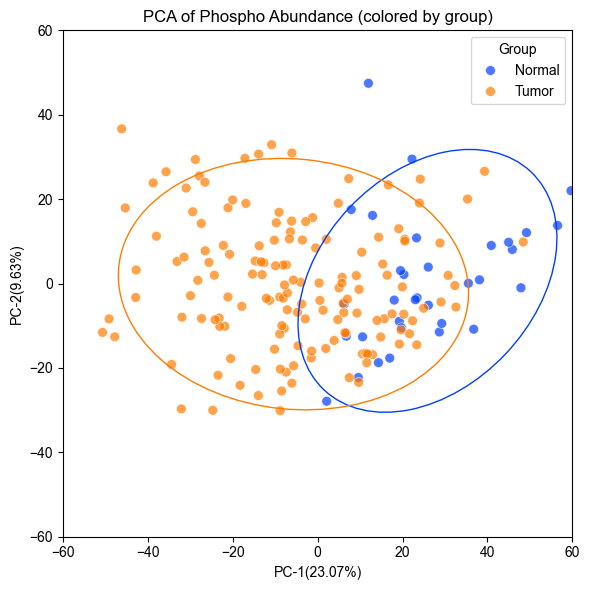

In [59]:
tag = "Phospho"
xlim = (-60,60)
ylim = (-60,60)
fig,pca = plot_pca1(data2, n=1, palette='bright', 
                    xlim=xlim, ylim=ylim, figsize=(6,6),
                    title=f"PCA of {tag} Abundance (colored by group)")

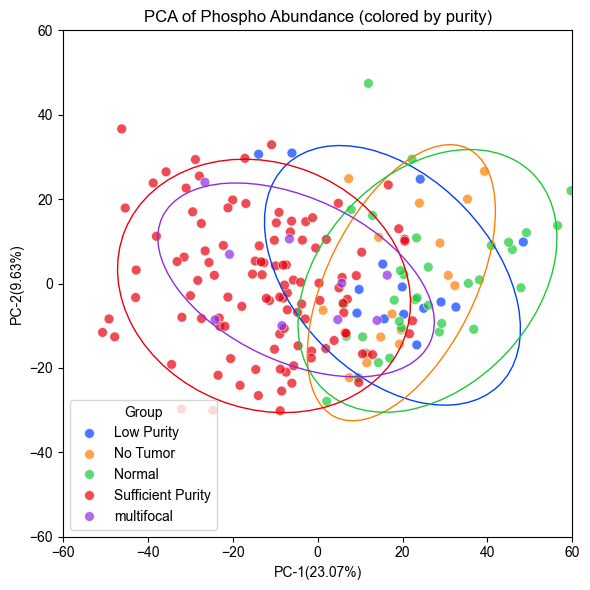

In [60]:
group_map = dict()
for i in tumors_included + normals:
    # print(i)
    if i in tumors_included:
        group_map[i] = purity_map.get(i, "Tumor")
    elif i in normals:
        group_map[i] = "Normal"
    else:
        group_map[i] = "Other"
data2['Group'] = data2.index.map(group_map)
data2 = data2.sort_values(by='Group')
fig,pca = plot_pca1(data2, n=1, palette='bright', 
                    xlim=xlim, ylim=ylim, figsize=(6,6),
                    title=f"PCA of {tag} Abundance (colored by purity)")

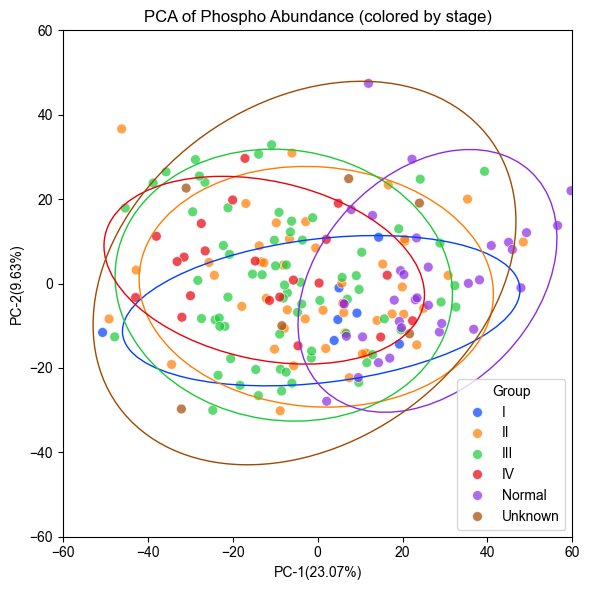

In [62]:
group_map = dict()
for i in tumors_included + normals:
    # print(i)
    if i in tumors_included:
        group_map[i] = re.sub("[ABC]",'',stage_map.get(i, "Tumor"))
    elif i in normals:
        group_map[i] = "Normal"
    else:
        group_map[i] = "Other"
data2['Group'] = data2.index.map(group_map)
data2 = data2.sort_values(by='Group')
fig,pca = plot_pca1(data2, n=1, palette='bright', 
                    xlim=xlim, ylim=xlim, figsize=(6,6),
                    title=f"PCA of {tag} Abundance (colored by stage)")

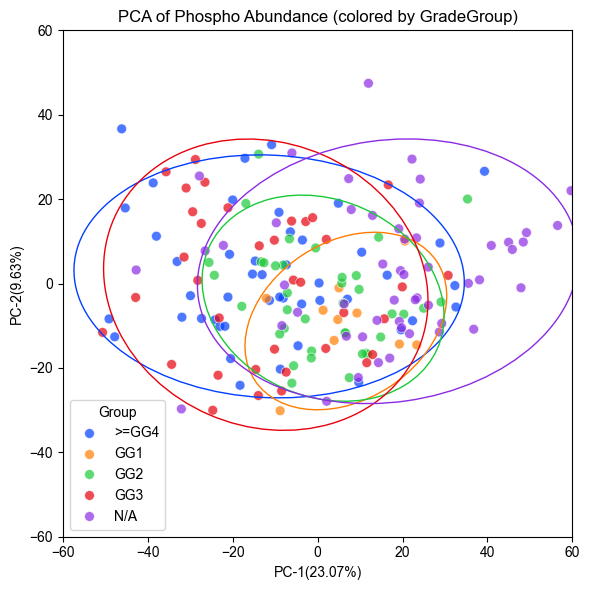

In [63]:
group_map = dict()
for i in tumors_included + normals:
    # print(i)
    if i in tumors_included:
        group_map[i] = str(gleason_map.get(i, "N/A"))
    elif i in normals:
        group_map[i] = "Normal"
    else:
        group_map[i] = "Other"
for i in group_map:
    group_map[i] = 'N/A' if not re.search("GG", group_map[i]) else group_map[i]
data2['Group'] = data2.index.map(group_map)
data2 = data2.sort_values(by='Group')
fig,pca = plot_pca1(data2, n=1, palette='bright', 
                    xlim=xlim, ylim=ylim, figsize=(6,6),
                    title=f"PCA of {tag} Abundance (colored by GradeGroup)")